# Mobile Game Dataset - Data Quality Audit

## Objective

In this notebook, I check the data before the main analysis starts.

I will look at:

- table size, columns, and data types
- missing values
- duplicate rows
- user coverage and user matching across tables
- date logic
- some simple quality issues in sessions and purchases


In [20]:
from pathlib import Path
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display

warnings.filterwarnings('ignore')
pd.options.display.float_format = '{:,.2f}'.format
plt.style.use('seaborn-v0_8-whitegrid')

## 1. Load the data

First, I load the three CSV files and take a quick look.


In [21]:
data_dir = Path('csv_files')

users = pd.read_csv(data_dir / 'users.csv')
sessions = pd.read_csv(data_dir / 'user_sessions.csv')
purchases = pd.read_csv(data_dir / 'user_purchases.csv')

tables = {
    'users': users,
    'sessions': sessions,
    'purchases': purchases,
}

shape_df = pd.DataFrame(
    [
        {'table': name, 'rows': df.shape[0], 'columns': df.shape[1]}
        for name, df in tables.items()
    ]
)

display(shape_df)

for name, df in tables.items():
    print(f'\n{name.upper()} - first 5 rows')
    display(df.head())


,table,rows,columns
0,users,6584,4
1,sessions,1699352,5
2,purchases,236270,3



USERS - first 5 rows


,user_id,join_date,os,country
0,157844,2021-12-05,Android,United States
1,583785,2022-06-25,iOS,Germany
2,152828,2021-12-04,iOS,United States
3,948940,2022-09-19,Android,Spain
4,1141021,2022-12-25,Android,Austria



SESSIONS - first 5 rows


,user_id,dt,session_id,session_duration_sec,level_completed
0,567638,2022-06-30,1656557867,3141,9.00
1,436895,2022-06-30,1656581942,2419,7.00
2,443735,2022-06-30,1656548061,6391,3.00
3,441407,2022-06-30,1656604859,1743,4.00
4,145625,2022-06-30,1656583677,1265,3.00



PURCHASES - first 5 rows


,user_id,dt,price_usd
0,424859,2022-06-02,5.65
1,360664,2022-06-02,2.33
2,424859,2022-06-02,5.65
3,470675,2022-06-02,2.25
4,522906,2022-06-02,3.51


## 2. Check columns and data types

Here I convert date columns and numeric columns to the correct type. Then I build a simple schema table.


In [22]:
users['user_id'] = pd.to_numeric(users['user_id'], errors='coerce').astype('Int64')
users['join_date'] = pd.to_datetime(users['join_date'], errors='coerce')

sessions['user_id'] = pd.to_numeric(sessions['user_id'], errors='coerce').astype('Int64')
sessions['dt'] = pd.to_datetime(sessions['dt'], errors='coerce')
sessions['session_id'] = pd.to_numeric(sessions['session_id'], errors='coerce').astype('Int64')
sessions['session_duration_sec'] = pd.to_numeric(sessions['session_duration_sec'], errors='coerce').astype('Int64')
sessions['level_completed'] = pd.to_numeric(sessions['level_completed'], errors='coerce').astype('Int64')

purchases['user_id'] = pd.to_numeric(purchases['user_id'], errors='coerce').astype('Int64')
purchases['dt'] = pd.to_datetime(purchases['dt'], errors='coerce')
purchases['price_usd'] = pd.to_numeric(purchases['price_usd'], errors='coerce')


def schema_table(df):
    return pd.DataFrame(
        {
            'column_name': df.columns,
            'dtype': [str(df[col].dtype) for col in df.columns],
            'null_count': [int(df[col].isna().sum()) for col in df.columns],
            'null_pct': [round(df[col].isna().mean() * 100, 2) for col in df.columns],
            'n_unique': [int(df[col].nunique(dropna=True)) for col in df.columns],
        }
    )


for name, df in [('users', users), ('sessions', sessions), ('purchases', purchases)]:
    print(f'\n{name.upper()} - schema')
    display(schema_table(df))



USERS - schema


,column_name,dtype,null_count,null_pct,n_unique
0,user_id,Int64,0,0.00,6584
1,join_date,datetime64[ns],0,0.00,449
2,os,object,0,0.00,2
3,country,object,1,0.02,124



SESSIONS - schema


,column_name,dtype,null_count,null_pct,n_unique
0,user_id,Int64,0,0.00,6422
1,dt,datetime64[ns],0,0.00,210
2,session_id,Int64,0,0.00,1615278
3,session_duration_sec,Int64,0,0.00,12862
4,level_completed,Int64,1398023,82.27,62



PURCHASES - schema


,column_name,dtype,null_count,null_pct,n_unique
0,user_id,Int64,0,0.00,37924
1,dt,datetime64[ns],0,0.00,210
2,price_usd,float64,109,0.05,2286


### Comment

- `level_completed` has many missing values. This does not always mean the player failed. It may mean no level was finished in that session.
- `price_usd` has only a few missing rows. This may come from a broken log or an incomplete payment event. These `price_usd` null rows should stay out.
- We also already see an important signal in the basic types and counts: `purchases` has more unique user IDs than `users`. This may be normal if the purchase export comes from a wider user universe, for example guest users, old users, or another source. But it also means I should be careful. I cannot assume every purchase user is part of the main user base in `users`.


## 3. Table overview

This is a short table to see the basic state of each dataset.


In [23]:
overview_df = pd.DataFrame(
    [
        {
            'table': 'users',
            'row_count': len(users),
            'column_count': users.shape[1],
            'unique_user_ids': users['user_id'].nunique(dropna=True),
            'exact_duplicate_rows': int(users.duplicated().sum()),
        },
        {
            'table': 'sessions',
            'row_count': len(sessions),
            'column_count': sessions.shape[1],
            'unique_user_ids': sessions['user_id'].nunique(dropna=True),
            'exact_duplicate_rows': int(sessions.duplicated().sum()),
        },
        {
            'table': 'purchases',
            'row_count': len(purchases),
            'column_count': purchases.shape[1],
            'unique_user_ids': purchases['user_id'].nunique(dropna=True),
            'exact_duplicate_rows': int(purchases.duplicated().sum()),
        },
    ]
)

display(overview_df)


,table,row_count,column_count,unique_user_ids,exact_duplicate_rows
0,users,6584,4,6584,0
1,sessions,1699352,5,6422,0
2,purchases,236270,3,37924,40977


### Comment

- In `purchases`, repeated full rows are also not automatically a problem. A user may buy more than one time on the same day, and this table only has daily `dt`, not full time.


## 4. Primary key checks

Now I check if each table has a stable key.


In [24]:
users_dup_user_id = users[users.duplicated(subset=['user_id'], keep=False)].sort_values('user_id')

users_pk_df = pd.DataFrame(
    {
        'expected_key': ['user_id'],
        'duplicate_user_id_rows': [len(users_dup_user_id)],
        'duplicate_user_ids': [users_dup_user_id['user_id'].nunique(dropna=True)],
    }
)

display(users_pk_df)


,expected_key,duplicate_user_id_rows,duplicate_user_ids
0,user_id,0,0


### Comment

`users` looks good here. There are no duplicate `user_id` values, so this table can be used as the main user dimension table.


In [25]:
session_id_check = pd.DataFrame(
    {
        'metric': [
            'rows',
            'unique session_id',
            'duplicate session_id rows',
            'exact duplicate rows'
        ],
        'value': [
            len(sessions),
            sessions['session_id'].nunique(dropna=True),
            int(sessions.duplicated(subset=['session_id']).sum()),
            int(sessions.duplicated().sum())
        ]
    }
)

display(session_id_check)


,metric,value
0,rows,1699352
1,unique session_id,1615278
2,duplicate session_id rows,84074
3,exact duplicate rows,0


### Comment

`session_id` is not unique. Because of that, I should not use only `session_id` as a primary key. For row-level work, `user_id + dt + session_id` looks safer.


In [26]:
purchase_pk_df = pd.DataFrame(
    {
        'metric': [
            'exact duplicate rows',
        ],
        'value': [
            int(purchases.duplicated().sum()),
        ]
    }
)

display(purchase_pk_df)


,metric,value
0,exact duplicate rows,40977


### Comment

Many purchase rows have the same `user_id + dt + price_usd` values. But this does not mean they are wrong. Since `dt` is only daily, the same user may really buy more than once on the same day for the same amount.


## 5. Missing values

Now I check null values in each table.


In [27]:
def null_table(df):
    out = pd.DataFrame(
        {
            'column_name': df.columns,
            'null_count': [int(df[col].isna().sum()) for col in df.columns],
            'null_pct': [round(df[col].isna().mean() * 100, 2) for col in df.columns],
        }
    )
    return out.sort_values(['null_count', 'column_name'], ascending=[False, True]).reset_index(drop=True)


for name, df in [('users', users), ('sessions', sessions), ('purchases', purchases)]:
    print(f'\n{name.upper()} - missing values')
    display(null_table(df))



USERS - missing values


,column_name,null_count,null_pct
0,country,1,0.02
1,join_date,0,0.00
2,os,0,0.00
3,user_id,0,0.00



SESSIONS - missing values


,column_name,null_count,null_pct
0,level_completed,1398023,82.27
1,dt,0,0.00
2,session_duration_sec,0,0.00
3,session_id,0,0.00
4,user_id,0,0.00



PURCHASES - missing values


,column_name,null_count,null_pct
0,price_usd,109,0.05
1,dt,0,0.00
2,user_id,0,0.00


### Comment

- `users` has only 1 missing value in `country`, so this is a small issue.
- `sessions.level_completed` has a very large missing rate, around 82%. This may mean no level was completed in many sessions.
- `purchases.price_usd` has 109 missing rows. This may mean a broken log, a failed payment flow, or an incomplete purchase event.


## 6. Exact duplicate rows

Here I check full-row repeats. For `purchases`, I need to be careful: a repeated full row is not always a bad duplicate, because the table only has day-level time.


In [28]:
dup_df = pd.DataFrame(
    [
        {
            'table': 'users',
            'same_full_rows': int(users.duplicated().sum()),
            'same_full_row_pct': round(users.duplicated().mean() * 100, 2),
        },
        {
            'table': 'sessions',
            'same_full_rows': int(sessions.duplicated().sum()),
            'same_full_row_pct': round(sessions.duplicated().mean() * 100, 2),
        },
        {
            'table': 'purchases',
            'same_full_rows': int(purchases.duplicated().sum()),
            'same_full_row_pct': round(purchases.duplicated().mean() * 100, 2),
        },
    ]
)

duplicate_purchase_keys = (
    purchases.loc[purchases.duplicated(keep=False), ['user_id', 'dt', 'price_usd']]
    .drop_duplicates()
    .sort_values(['user_id', 'dt', 'price_usd'])
    .head(5)
)

repeated_full_purchase_rows = (
    duplicate_purchase_keys
    .merge(purchases, on=['user_id', 'dt', 'price_usd'], how='left')
    .sort_values(['user_id', 'dt', 'price_usd'])
    .reset_index(drop=True)
)

display(dup_df)

print('PURCHASES - example repeated full rows')
display(repeated_full_purchase_rows)


,table,same_full_rows,same_full_row_pct
0,users,0,0.00
1,sessions,0,0.00
2,purchases,40977,17.34


PURCHASES - example repeated full rows


,user_id,dt,price_usd
0,2008,2022-08-08,2.28
1,2008,2022-08-08,2.28
2,2008,2022-08-08,5.57
3,2008,2022-08-08,5.57
4,2008,2022-08-08,5.57
5,2023,2022-08-12,23.69
6,2023,2022-08-12,23.69
7,2099,2022-09-28,0.86
8,2099,2022-09-28,0.86
9,2099,2022-09-28,0.86


### Comment

- `users` and `sessions` do not have same full rows.
- `purchases` has many same full rows, but this is not enough to call them bad rows, because `dt` is daily, repeated same-day purchases can be real behavior.


## 7. User coverage across tables

This section compares the user universe in the raw tables. Here I want to see the difference between all purchase users and purchase users that also exist in `users`.


In [29]:
users_set = set(users['user_id'].dropna())
sessions_set = set(sessions['user_id'].dropna())
purchases_set = set(purchases['user_id'].dropna())
purchase_users_in_users = set(purchases.loc[purchases['user_id'].isin(users_set), 'user_id'].dropna())

coverage_df = pd.DataFrame(
    {
        'metric': [
            'unique users in users table',
            'unique users with sessions',
            'unique users with purchases',
            'unique purchase users also found in users table',
            'unique users in users table with no purchase',
        ],
        'value': [
            len(users_set),
            len(sessions_set),
            len(purchases_set),
            len(purchase_users_in_users),
            len(users_set - purchase_users_in_users),
        ],
    }
)

display(coverage_df)


,metric,value
0,unique users in users table,6584
1,unique users with sessions,6422
2,unique users with purchases,37924
3,unique purchase users also found in users table,6270
4,unique users in users table with no purchase,314


### Comment

- Now this table shows two purchase views. `unique users with purchases` is the full purchase universe. `unique purchase users also found in users table` is the smaller group that can join safely to `users`.
- For raw total revenue from the purchase file, I would use the full purchase universe. But for revenue per registered user, payer rate, cohort revenue, or segmented monetization, I would use only `unique purchase users also found in users table`.


## 8. Date checks

Now I check if dates make sense. This is important for cohort and retention analysis.


In [30]:
date_range_df = pd.DataFrame(
    [
        {
            'table': 'users',
            'date_column': 'join_date',
            'min_date': users['join_date'].min(),
            'max_date': users['join_date'].max(),
        },
        {
            'table': 'sessions',
            'date_column': 'dt',
            'min_date': sessions['dt'].min(),
            'max_date': sessions['dt'].max(),
        },
        {
            'table': 'purchases',
            'date_column': 'dt',
            'min_date': purchases['dt'].min(),
            'max_date': purchases['dt'].max(),
        },
    ]
)

sessions_join = sessions.merge(users[['user_id', 'join_date']], on='user_id', how='left')
purchases_in_users = purchases[purchases['user_id'].isin(users_set)].merge(users[['user_id', 'join_date']], on='user_id', how='left')

date_logic_df = pd.DataFrame(
    {
        'check': [
            'sessions before join',
            'purchases before join',
            'joined before session window'
        ],
        'value': [
            int((sessions_join['dt'] < sessions_join['join_date']).sum()),
            int((purchases_in_users['dt'] < purchases_in_users['join_date']).sum()),
            int((users['join_date'] < sessions['dt'].min()).sum())
        ]
    }
)

display(date_range_df)
display(date_logic_df)


,table,date_column,min_date,max_date
0,users,join_date,2021-07-09,2022-12-25
1,sessions,dt,2022-06-02,2022-12-28
2,purchases,dt,2022-06-02,2022-12-28


,check,value
0,sessions before join,0
1,purchases before join,0
2,joined before session window,2316


### Comment

- For users that exist in the `users` table, I do not see sessions or purchases before `join_date`. That is good.
- The session table starts on `2022-06-02`, but 2,316 users joined before this date. This means I cannot see the first days of those older users inside this dataset. For example, if a user joined in January 2022, their day 1 or day 7 activity is not visible here.


## 9. Session checks

This section looks at session duration and `level_completed`.


In [31]:
session_checks = []

for label, mask in [
    ('negative duration', sessions['session_duration_sec'] < 0),
    ('zero duration', sessions['session_duration_sec'] == 0),
    ('duration > 2 hours', sessions['session_duration_sec'] > 7200),
    ('duration > 10 hours', sessions['session_duration_sec'] > 36000),
]:
    session_checks.append(
        {
            'check': label,
            '# of sessions': int(mask.sum()),
            '# of users': int(sessions.loc[mask, 'user_id'].nunique()),
        }
    )

session_quality_df = pd.DataFrame(session_checks)

display(session_quality_df)


,check,# of sessions,# of users
0,negative duration,0,0
1,zero duration,35900,4987
2,duration > 2 hours,9486,2322
3,duration > 10 hours,170,134


### Comment

- `# of sessions` means how many session rows match the rule.
- `# of users` means how many unique users are affected by that rule.
- There are no negative durations, which is good. But there are many zero-duration sessions, and they affect many users too.


## 10. Purchase checks

This section looks at amount quality and repeated purchase patterns.


In [32]:
purchase_quality_df = pd.DataFrame(
    {
        'check': [
            'negative price',
            'zero price',
            'missing price',
            '# of purchase rows from unregistered users',
            '# of unique unregistered users in purchases'
        ],
        'value': [
            int((purchases['price_usd'] < 0).sum()),
            int((purchases['price_usd'] == 0).sum()),
            int(purchases['price_usd'].isna().sum()),
            int((~purchases['user_id'].isin(users_set)).sum()),
            int(purchases.loc[~purchases['user_id'].isin(users_set), 'user_id'].nunique())
        ]
    }
)

display(purchase_quality_df)


,check,value
0,negative price,0
1,zero price,0
2,missing price,109
3,# of purchase rows from unregistered users,89644
4,# of unique unregistered users in purchases,31654


### Comment

- I do not see negative or zero prices, so that part looks okay.
- There are user IDs in `purchases` that are not in the `users` table. This means the purchase file has a bigger user universe than the user table.

## 11. Category checks

Here I check if `os` and `country` values look clean.


In [33]:
os_check = pd.DataFrame(
    {
        'metric': ['raw unique values', 'unique after lower + trim'],
        'users.os': [
            users['os'].dropna().nunique(),
            users['os'].dropna().astype(str).str.strip().str.lower().nunique(),
        ],
    }
)

country_check = pd.DataFrame(
    {
        'metric': ['raw unique values', 'unique after lower + trim'],
        'users.country': [
            users['country'].dropna().nunique(),
            users['country'].dropna().astype(str).str.strip().str.lower().nunique(),
        ],
    }
)

display(os_check)
display(country_check)

print('OS values')
display(users['os'].value_counts(dropna=False).reset_index(name='row_count'))

print('Top 15 countries')
display(users['country'].value_counts(dropna=False).head(15).reset_index(name='row_count'))


,metric,users.os
0,raw unique values,2
1,unique after lower + trim,2


,metric,users.country
0,raw unique values,124
1,unique after lower + trim,124


OS values


,os,row_count
0,Android,4266
1,iOS,2318


Top 15 countries


,country,row_count
0,United Kingdom,1531
1,United States,1439
2,Germany,418
3,Spain,260
4,Chile,237
5,Italy,189
6,France,187
7,Poland,145
8,Canada,130
9,Brazil,121


### Comment

- `os` looks clean. It has only two clear values: Android and iOS.
- `country` also looks mostly clean from a first check. I do not see a strong text standardization problem here.

## 12. Simple distribution checks

For the clipped histograms, I use the 99th percentile as an upper cap. A small number of very high values can stretch the chart and hide the pattern of most users. This keeps the visual easier to read and compare, while the original data is still kept for the real analysis.


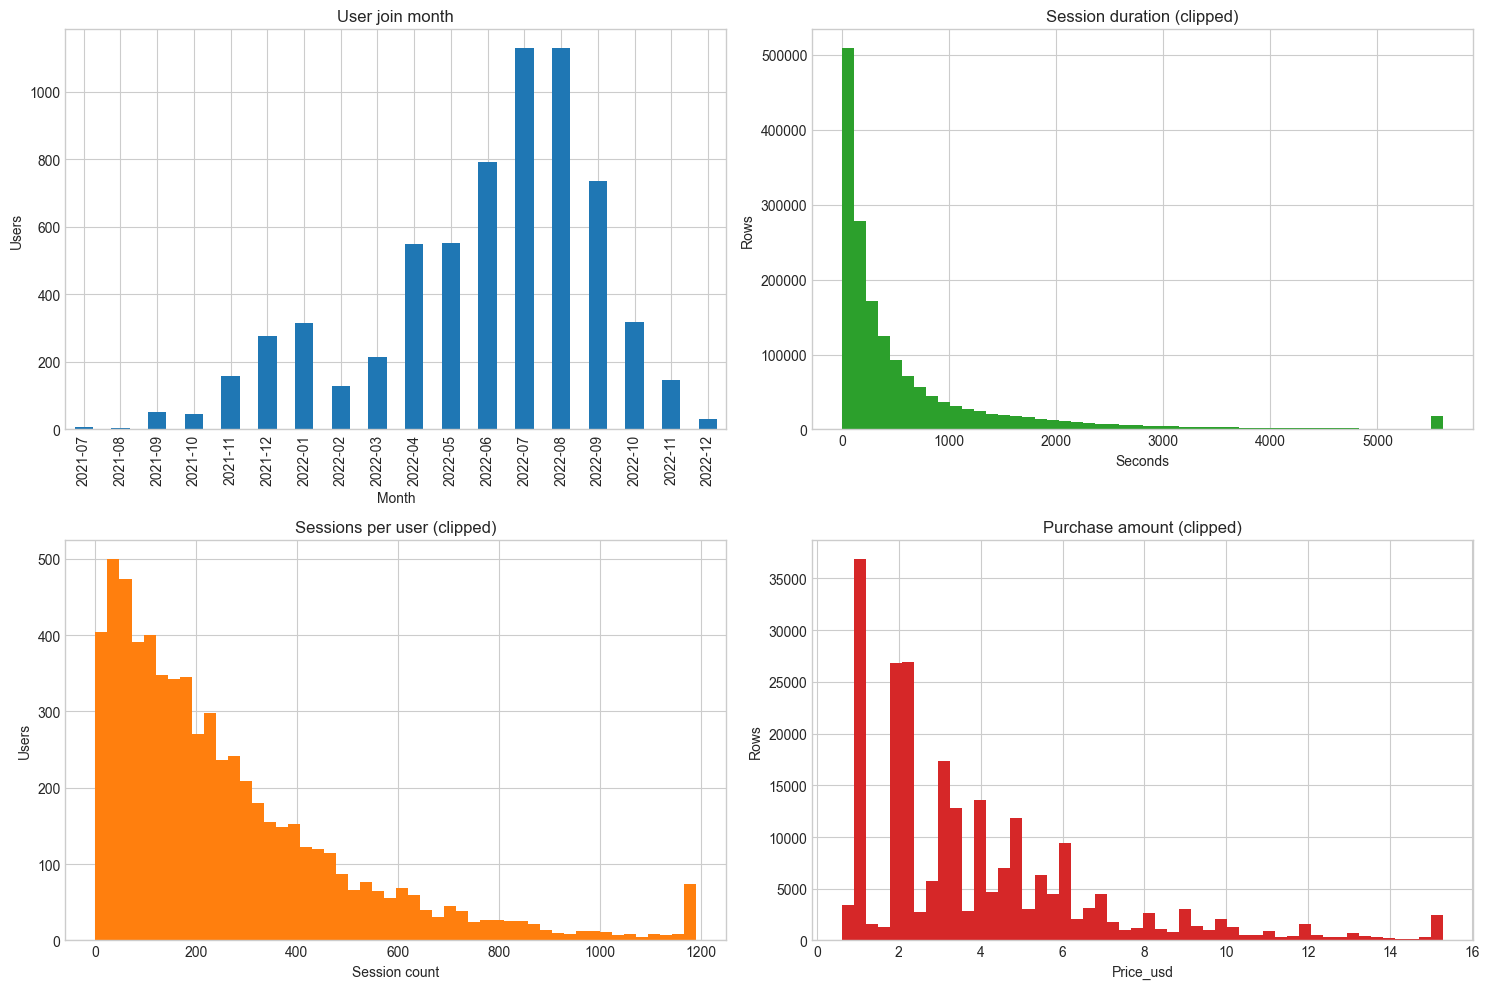

In [34]:
sessions_per_user = sessions.groupby('user_id').size()
purchases_per_user = purchases.groupby('user_id').size()

join_month = users['join_date'].dt.to_period('M').astype(str).value_counts().sort_index()
session_duration_plot = sessions['session_duration_sec'].dropna().clip(upper=sessions['session_duration_sec'].quantile(0.99))
purchase_amount_plot = purchases['price_usd'].dropna().clip(upper=purchases['price_usd'].quantile(0.99))

fig, axes = plt.subplots(2, 2, figsize=(15, 10))

join_month.plot(kind='bar', ax=axes[0, 0], color='#1f77b4')
axes[0, 0].set_title('User join month')
axes[0, 0].set_xlabel('Month')
axes[0, 0].set_ylabel('Users')

axes[0, 1].hist(session_duration_plot, bins=50, color='#2ca02c')
axes[0, 1].set_title('Session duration (clipped)')
axes[0, 1].set_xlabel('Seconds')
axes[0, 1].set_ylabel('Rows')

axes[1, 0].hist(sessions_per_user.clip(upper=sessions_per_user.quantile(0.99)), bins=50, color='#ff7f0e')
axes[1, 0].set_title('Sessions per user (clipped)')
axes[1, 0].set_xlabel('Session count')
axes[1, 0].set_ylabel('Users')

axes[1, 1].hist(purchase_amount_plot, bins=50, color='#d62728')
axes[1, 1].set_title('Purchase amount (clipped)')
axes[1, 1].set_xlabel('Price_usd')
axes[1, 1].set_ylabel('Rows')

plt.tight_layout()
plt.show()


### Comment

- The distributions are right-skewed, which is normal for game data.